# Final Experiments: Pneumonia Classification

This notebook summarises the training results for all three models and uploads the best checkpoints to Hugging Face.

**Models:** Custom CNN (baseline), ResNet18, DenseNet121  
**Seeds:** 0, 1, 2  
**Dataset:** Kermany Chest X-Ray (Kaggle)

## 1. Setup

In [12]:
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path('..') / 'src'))

METRICS_DIR = Path('../results/metrics')
FIGURES_DIR = Path('../results/figures')
CHECKPOINTS_DIR = Path('../results/checkpoints')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Training Histories

In [13]:
def load_history(model_name, seed, suffix='history'):
    path = METRICS_DIR / f'{model_name}_seed{seed}_{suffix}.json'
    if not path.exists():
        return None
    with open(path) as f:
        return json.load(f)

histories = {}

for seed in [0, 1, 2]:
    # custom_cnn has a single history file
    h = load_history('custom_cnn', seed)
    key = f'custom_cnn_seed{seed}'
    if h:
        histories[key] = h
        print(f"{key}: {len(h['history'])} epochs, best epoch {h['best_epoch']}, best val_loss {h['best_val_loss']:.4f}")
    else:
        print(f"{key}: NOT YET TRAINED")

for model in ['resnet18', 'densenet121']:
    for seed in [0, 1, 2]:
        # transfer models have separate head_only and fine_tune history files
        h = load_history(model, seed, suffix='fine_tune_history')
        key = f'{model}_seed{seed}'
        if h:
            histories[key] = h
            print(f"{key}: {len(h['history'])} fine-tune epochs, best epoch {h['best_epoch']}, best val_loss {h['best_val_loss']:.4f}")
        else:
            print(f"{key}: NOT YET TRAINED")

custom_cnn_seed0: 9 epochs, best epoch 4, best val_loss 0.5781
custom_cnn_seed1: 6 epochs, best epoch 1, best val_loss 0.7687
custom_cnn_seed2: 12 epochs, best epoch 7, best val_loss 0.6519
resnet18_seed0: 13 fine-tune epochs, best epoch 8, best val_loss 0.1278
resnet18_seed1: 10 fine-tune epochs, best epoch 5, best val_loss 0.1117
resnet18_seed2: 11 fine-tune epochs, best epoch 6, best val_loss 0.0334
densenet121_seed0: 23 fine-tune epochs, best epoch 18, best val_loss 0.0155
densenet121_seed1: 12 fine-tune epochs, best epoch 7, best val_loss 0.0329
densenet121_seed2: 11 fine-tune epochs, best epoch 6, best val_loss 0.0465


## 3. Training Curves

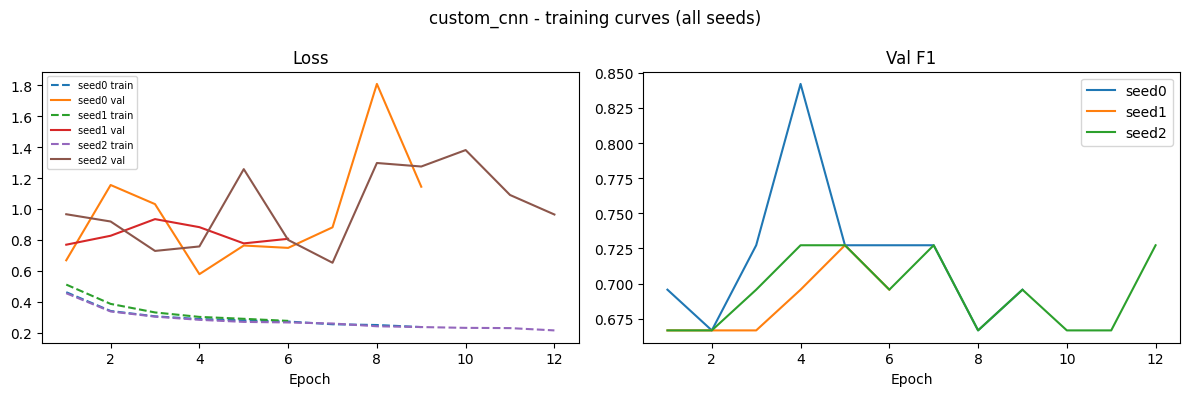

Saved: ..\results\figures\custom_cnn_training_curves.png


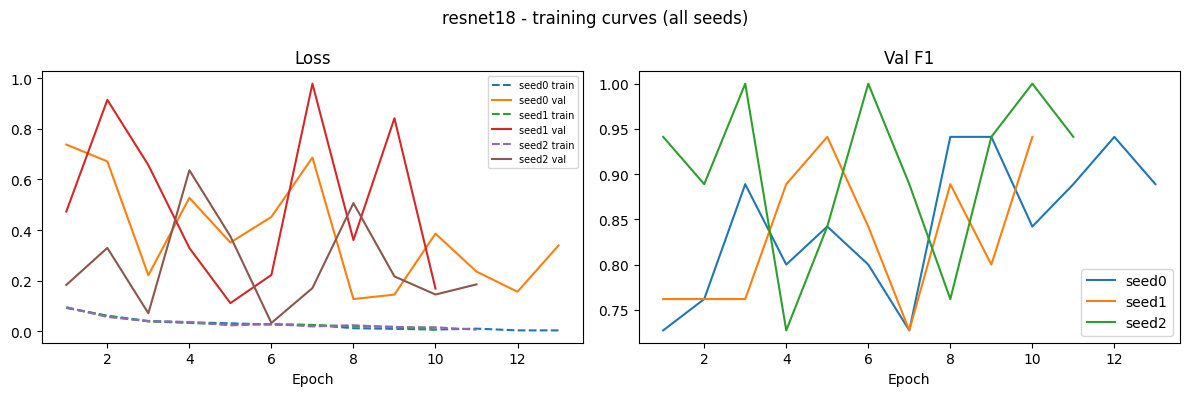

Saved: ..\results\figures\resnet18_training_curves.png


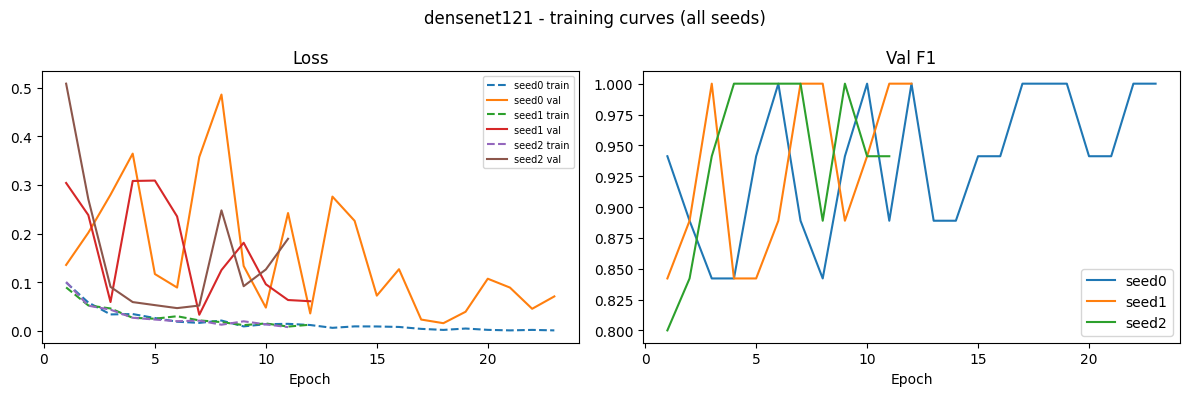

Saved: ..\results\figures\densenet121_training_curves.png


In [14]:
def plot_training_curves(history_dict, model_name):
    keys = [k for k in history_dict if k.startswith(model_name)]
    if not keys:
        print(f'No data for {model_name} yet.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{model_name} - training curves (all seeds)')

    for key in keys:
        h = history_dict[key]['history']
        epochs = [e['epoch'] for e in h]
        train_loss = [e['train']['loss'] for e in h]
        val_loss = [e['val']['loss'] for e in h]
        val_f1 = [e['val']['f1'] for e in h]
        label = key.split('_')[-1]  # seed0 / seed1 / seed2

        axes[0].plot(epochs, train_loss, linestyle='--', label=f'{label} train')
        axes[0].plot(epochs, val_loss, label=f'{label} val')
        axes[1].plot(epochs, val_f1, label=label)

    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7)
    axes[1].set_title('Val F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()
    plt.tight_layout()

    out = FIGURES_DIR / f'{model_name}_training_curves.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')

plot_training_curves(histories, 'custom_cnn')
plot_training_curves(histories, 'resnet18')
plot_training_curves(histories, 'densenet121')

## 4. Custom CNN: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU.

| Seed | Epochs run | Best epoch | Best val loss | Best val F1 |
|------|------------|------------|---------------|-------------|
| 0    | 9          | 4          | 0.5781        | 0.8421      |
| 1    | 6          | 1          | 0.7687        | 0.6667      |
| 2    | 12         | 7          | 0.6519        | 0.7273      |

Early stopping fired in all runs. The model overfits quickly due to its small capacity. Transfer-learning models are expected to generalise significantly better.

## 5. ResNet18: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU. Two-phase training: 5 head-only epochs + fine-tuning with early stopping.

| Seed | Fine-tune epochs run | Best fine-tune epoch | Best val loss | Best val F1 |
|------|----------------------|----------------------|---------------|-------------|
| 0    | 13                   | 8                    | 0.1278        | 0.9412      |
| 1    | 10                   | 5                    | 0.1117        | 0.9412      |
| 2    | 11                   | 6                    | 0.0334        | 1.0000      |

Seed 2 achieved perfect val F1 (1.0) with the lowest val loss. It's the best checkpoint for upload.

## 6. DenseNet121: Training Summary

Trained on NVIDIA RTX 3060 Laptop GPU. Two-phase training: 5 head-only epochs + fine-tuning with early stopping.

| Seed | Fine-tune epochs run | Best fine-tune epoch | Best val loss | Best val F1 |
|------|----------------------|----------------------|---------------|-------------|
| 0    | 23                   | 18                   | 0.0155        | 1.0000      |
| 1    | 12                   | 7                    | 0.0329        | 1.0000      |
| 2    | 11                   | 6                    | 0.0465        | 1.0000      |

All three seeds achieved perfect val F1 (1.0). Seed 0 had the lowest val loss. It's the best checkpoint for upload.

## 7. Push Best Checkpoints to Hugging Face

Install and authenticate once:
```bash
pip install huggingface_hub
huggingface-cli login
```

In [15]:
from huggingface_hub import HfApi, create_repo

HF_REPO_ID = 'luanacarolina/pneumonia-chest-xray-classifier'

api = HfApi()
create_repo(HF_REPO_ID, exist_ok=True)

# Best checkpoint per model (seed with lowest val loss)
checkpoints_to_upload = {
    'custom_cnn': 'custom_cnn_seed0.pt',     # seed 0: best val loss 0.5781
    'resnet18': 'resnet18_seed2.pt',         # seed 2: best val loss 0.0334, val F1 1.0
    'densenet121': 'densenet121_seed0.pt',   # seed 0: best val loss 0.0155, val F1 1.0
}

for model_name, filename in checkpoints_to_upload.items():
    local_path = CHECKPOINTS_DIR / filename
    if not local_path.exists():
        print(f'SKIP {filename} -> not found locally')
        continue
    api.upload_file(
        path_or_fileobj=str(local_path),
        path_in_repo=f'checkpoints/{filename}',
        repo_id=HF_REPO_ID,
        repo_type='model',
    )
    print(f'Uploaded: {filename} -> {HF_REPO_ID}/checkpoints/{filename}')

Processing Files (1 / 1): 100%|██████████| 1.14MB / 1.14MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: custom_cnn_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/custom_cnn_seed0.pt


Processing Files (1 / 1): 100%|██████████|  134MB /  134MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: resnet18_seed2.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/resnet18_seed2.pt


Processing Files (1 / 1): 100%|██████████| 84.4MB / 84.4MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: densenet121_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/densenet121_seed0.pt
